# Week 2 · Data Wrangling & Hygiene
### FinTech & AI Engineering — MSc Banking & Finance

---

## 🧭 Where we are in the build

Last week you performed a full analyst workflow **by hand** on data that was, frankly, on its best behavior. This week the data misbehaves — because real financial data always does. Duplicated rows, silent gaps, mismatched calendars, impossible prices, values that simply are not there.

Here is the uncomfortable truth that makes this week matter:

> **Dirty data almost never crashes a model. It quietly bends one.** A duplicated row nudges a volatility estimate; a badly filled gap manufactures a correlation; a peek into the future makes a worthless strategy look brilliant. The error message you never see is the most expensive one in finance.

In the product you are building across these 11 weeks, this week's work becomes the **Data Quality Agent** — the gatekeeper that inspects every dataset before any other agent is allowed to touch it. And per the iron rule:

> **Human first, agent second.** Before you may delegate cleaning to an agent, you must clean by hand, and — harder — you must be able to *judge* a cleaning job. Today you learn both.

**The week's centerpiece is the masking experiment**: we will hide values whose true level we know, ask each repair method to reconstruct them, and score the reconstruction. That hide-and-score loop is your first real **eval suite** — governance instrument #2 from the course manifesto. Trust is earned statistically, starting today.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Run a systematic **hygiene audit** on any price series (duplicates, gaps, types, impossible values) before analysis.
2. Explain why aligning assets with different trading calendars *manufactures* missing data, and defend an alignment choice.
3. Classify missing data as **MCAR, MAR, or MNAR** and explain why the repair menu depends on the diagnosis.
4. Implement the core imputation toolkit — fills, interpolation, rolling statistics, K-NN, MICE — and state each method's assumptions.
5. Evaluate imputation quality with **MAE, RMSE, MAPE/sMAPE and the variance ratio**, via a masking experiment you design yourself.
6. Recognize **look-ahead bias** in a cleaning rule and state which methods are admissible in real time.
7. Write the first draft of a **Cleaning Agent's rulebook**: executable assertions a dataset must pass.

## 🗺️ How to use this notebook

Run cells top to bottom (`Shift+Enter`). Markdown carries the theory, code carries the practice, every step is commented. The notebook reuses **last week's `data/` folder**; if files or internet are missing it falls back to synthetic data, so it always runs. The Polars section at the end is **optional**.

---
# 1 · Why hygiene is risk management, not housekeeping

A tidy, documented dataset is three things at once: **risk mitigation** (upstream errors amplify downstream, especially once leverage or automation is attached), **reproducibility insurance** (you, in three months, are a different person), and **credibility capital** (the first wrong number in a meeting is the last number anyone believes).

## The five tidy-data principles (Wickham)

| # | Principle | Financial violation you will actually meet |
|---|---|---|
| 1 | Each **variable** in its own column | `"USD-Price"` packed into one string |
| 2 | Each **observation** in its own row | quarterly results stacked horizontally, Q1–Q4 as columns |
| 3 | One **observational unit** per table | trades, accounts and clients in one sheet |
| 4 | Values are **atomic** | a JSON blob or a comma-separated list inside a cell |
| 5 | Explicit **types and names** | dates as strings, prices as text with `$`, columns named `Unnamed: 3` |

Use `snake_case` names and ISO-8601 dates (`YYYY-MM-DD`) and half the battle is already won.

## This week's additions to the toolkit

| Library | What it adds this week |
|---|---|
| **`pandas`** | still ~90% of the work: `isna`, `ffill`, `interpolate`, `rolling`, calendar logic |
| **`scikit-learn`** | industrial imputers: `KNNImputer`, `IterativeImputer` (MICE), `StandardScaler` |
| **`matplotlib`** | missingness maps, method comparisons, the look-ahead crime scene |
| *(optional)* **`polars`** | a modern, multi-threaded DataFrame engine — a taste at the end |

```bash
pip install pandas numpy matplotlib scikit-learn yfinance
```

In [1]:
# ============================================================
# Cell 1 — Imports and environment check
# ============================================================
# Same conventions as Week 1: short universal aliases (pd, np, plt),
# one seeded random generator so the whole class sees identical numbers.

import sys, time                     # interpreter info; wall-clock timing for the cost ledger
from pathlib import Path             # cross-platform file paths

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn                                   # scikit-learn: today's new tool
from sklearn.experimental import enable_iterative_imputer   # unlocks IterativeImputer (still "experimental" flag)
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RNG = np.random.default_rng(seed=42)   # reproducibility for anything random today

print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("sklearn :", sklearn.__version__)
print("✅ Environment ready.")

Python  : 3.14.5
pandas  : 3.0.3
numpy   : 2.4.6
sklearn : 1.9.0
✅ Environment ready.


---
# 2 · Getting the data — the same trio, on purpose

We keep last week's three assets — **SPY** (equities), **EUR/USD** (FX), **BTC** (crypto) — for a pedagogical reason: you already know what these series *look like when healthy*. That knowledge is exactly what an auditor needs. And the trio hides this week's central problem in plain sight:

| Asset | Trading calendar |
|---|---|
| SPY | business days only — closed weekends & US holidays |
| EUR/USD | business days (interbank convention) |
| **BTC** | **every single day** — crypto never sleeps |

Put these on one table and *someone* must decide what a stock price "is" on a Saturday. That decision — not a glitch, not a bug — will be our first source of missing data.

**Data path, in order of preference:**
1. The `data/` folder from Week 1 (`spy.csv`, `eurusd.csv`, `btc.csv`) — if you still have it, nothing to do.
2. The download cell below refreshes the files via `yfinance` (needs internet).
3. No files, no internet → a synthetic fallback generates GBM twins **with realistic calendars** (SPY/EURUSD on business days, BTC on all days), so every experiment below still works.

In [2]:
# ============================================================
# Cell 2 — (Re)download via yfinance, defensively
# ============================================================
# Unlike Week 1 we wrap the download in try/except: a notebook that
# dies on a wifi hiccup in a live demo is a badly engineered notebook.
# Defensive I/O is itself a hygiene habit.

Path("data").mkdir(exist_ok=True)

TICKERS = {"spy": "SPY", "eurusd": "EURUSD=X", "btc": "BTC-USD", "eth": "ETH-USD", "athex": "AETF.AT"}   # Yahoo's special FX/crypto symbols

try:
    import yfinance as yf
    for stem, ticker in TICKERS.items():
        data = yf.download(
            ticker,
            start="2017-05-27",          # BTC's first Yahoo date — the binding asset from Week 1
            auto_adjust=True,            # Close adjusted for dividends/splits
            multi_level_index=False,     # flat header -> clean CSV
        )
        if len(data) == 0:
            raise RuntimeError(f"empty download for {ticker}")
        data.to_csv(f"data/{stem}.csv")
        print(f"✅ {stem}: {len(data):,} rows saved")
except Exception as e:
    print(f"⚠️  Download unavailable ({type(e).__name__}). "
          f"Will use existing files in data/ or the synthetic fallback below.")

[*********************100%***********************]  1 of 1 completed


✅ spy: 2,343 rows saved


[*********************100%***********************]  1 of 1 completed


✅ eurusd: 2,425 rows saved


[*********************100%***********************]  1 of 1 completed


✅ btc: 3,407 rows saved


[*********************100%***********************]  1 of 1 completed


✅ eth: 3,241 rows saved


[*********************100%***********************]  1 of 1 completed

✅ athex: 2,315 rows saved


In [3]:
# ============================================================
# Cell 3 — Loader + synthetic fallback (calendar-aware GBM)
# ============================================================
# Same loader philosophy as Week 1 (defensive, flexible, honest),
# with one upgrade: the fallback now mimics each asset's REAL calendar,
# because this week the calendar itself is the subject.

DATA_DIR = Path("data")

ASSETS = {
    "SPY":    {"stem": "spy",    "label": "S&P 500 ETF (equities)", "cal": "B",
               "mu": 0.10, "sigma": 0.18, "s0": 200.0, "rho": 0.80},
    "EURUSD": {"stem": "eurusd", "label": "EUR/USD (FX)",           "cal": "B",
               "mu": 0.00, "sigma": 0.08, "s0": 1.25,  "rho": 0.15},
    "BTC":    {"stem": "btc",    "label": "Bitcoin (crypto)",       "cal": "D",
               "mu": 0.45, "sigma": 0.75, "s0": 450.0, "rho": 0.45},
    "ATHEX":  {"stem": "athex",    "label": "Athex (Large Cap Index)",       "cal": "B",
               "mu": 0.05, "sigma": 0.25, "s0": 750.0, "rho": 0.75},

    "ΕΤΗ":    {"stem": "eth",    "label": "Ethereum (crypto)",       "cal": "D",
               "mu": 0.30, "sigma": 0.70, "s0": 8000.0, "rho": 0.45},
}

# cal="B": business days (Mon–Fri).  cal="D": every calendar day.
# mu/sigma/s0: annual drift, volatility, starting price — caricature-realistic
# (BTC several times more volatile than SPY).
# rho: loading on a COMMON market factor, so synthetic assets co-move the way
# real ones do — otherwise the multivariate methods below would face a world
# with no cross-sectional signal at all, which real finance never is.

def load_price_file(stem: str) -> pd.Series | None:
    """Load a Close-price series from data/{stem}.csv or .xlsx; None if absent/broken."""
    for ext in (".csv", ".xlsx"):
        f = DATA_DIR / f"{stem}{ext}"
        if not f.exists():
            continue
        df = pd.read_csv(f) if ext == ".csv" else pd.read_excel(f)
        df.columns = [str(c).strip() for c in df.columns]          # stray whitespace: classic
        date_col = next((c for c in df.columns if c.lower().startswith("date")), df.columns[0])
        px_col   = next((c for c in df.columns if c.lower() in ("close", "adj close", "adj_close")), None)
        if px_col is None:
            return None
        s = pd.Series(
            pd.to_numeric(df[px_col], errors="coerce").values,     # text -> number, junk -> NaN
            index=pd.to_datetime(df[date_col], errors="coerce"),
        )
        s = s[s.index.notna()].sort_index()
        return s if len(s) else None
    return None

START, END = "2017-05-27", "2025-09-01"
_MASTER = pd.date_range(START, END, freq="D")
_COMMON_Z = pd.Series(RNG.standard_normal(len(_MASTER)), index=_MASTER)  # one market factor, drawn once

def generate_gbm(cal: str, mu: float, sigma: float, s0: float, rho: float) -> pd.Series:
    """Exact GBM discretization (Week 1) on the asset's own calendar.
    Each daily shock = rho·(common market shock) + sqrt(1−rho²)·(own shock),
    a one-factor model — the simplest way to make assets co-move."""
    idx = pd.date_range(START, END, freq=cal)
    n_per_year = 252 if cal == "B" else 365
    dt = 1.0 / n_per_year
    own = RNG.standard_normal(len(idx) - 1)
    z = rho * _COMMON_Z.loc[idx[1:]].values + np.sqrt(1.0 - rho**2) * own
    log_steps = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    prices = s0 * np.exp(np.concatenate([[0.0], np.cumsum(log_steps)]))
    return pd.Series(prices, index=idx)

raw = {}                                  # name -> raw (UNaligned!) price series
for name, meta in ASSETS.items():
    s = load_price_file(meta["stem"])
    src = "real file"
    if s is None:
        s = generate_gbm(meta["cal"], meta["mu"], meta["sigma"], meta["s0"], meta["rho"])
        src = "SYNTHETIC fallback"
    raw[name] = s.rename(name)
    print(f"{name:7s} | {src:18s} | {len(s):>5,} rows | {s.index[0].date()} → {s.index[-1].date()}")

# NOTE the deliberate difference from Week 1: we do NOT align the assets yet.
# Alignment is not preprocessing this week — it is the lesson.

SPY     | real file          | 2,343 rows | 2017-05-30 → 2026-09-23
EURUSD  | real file          | 2,425 rows | 2017-05-29 → 2026-09-23
BTC     | real file          | 3,407 rows | 2017-05-27 → 2026-09-23
ATHEX   | real file          | 2,315 rows | 2017-05-29 → 2026-09-23
ΕΤΗ     | real file          | 3,241 rows | 2017-11-09 → 2026-09-23


---
# 3 · The hygiene audit — interrogate before you trust

Pilots do not "have a look at" an aircraft; they run a **pre-flight checklist**, the same one every time, because eyeballing misses exactly the faults that matter. We now write that checklist for a price series. Six questions, each mapping to a concrete failure seen in real vendor data:

| Check | What can actually go wrong |
|---|---|
| **Duplicated dates** | vendor appends a correction without deleting the original → every statistic double-counts that day |
| **Non-numeric types** | `"1,234.50"` or `" 105.3 "` loaded as *text* → means and returns silently fail or coerce |
| **Impossible values** | zero or negative prices (placeholder `-999`, failed scrape) → log returns explode |
| **Future timestamps** | a `2052-01-01` row from a fat-fingered upload → "your data predicts the future" |
| **Extreme jumps** | a 10,000% "return" is a decimal-point error or an unadjusted split, not a market event |
| **Calendar gaps** | dates missing *relative to the asset's own expected calendar* — the subtlest one, and this week's star |

One professional habit embodied below: the audit **reports, it does not repair**. Diagnosis and treatment are separate steps, so the treatment is always a conscious, documented decision — never a side effect.

In [4]:
# ============================================================
# Cell 4 — audit_price_series(): the pre-flight checklist as code
# ============================================================

def audit_price_series(s: pd.Series, cal: str,
                       stale_threshold: int = 5) -> dict:
    """Run the eight-point hygiene audit. Returns findings; repairs NOTHING."""
    idx = s.index

    # 1) duplicated dates -----------------------------------------------
    n_dup = int(idx.duplicated().sum())

    # 2) type check ------------------------------------------------------
    is_numeric = pd.api.types.is_numeric_dtype(s)

    # 3) impossible values ----------------------------------------------
    n_nonpos  = int((s <= 0).sum())
    n_navalue = int(s.isna().sum())

    # 4) future timestamps ----------------------------------------------
    n_future = int((idx > pd.Timestamp.today()).sum())

    # 5) extreme jumps ---------------------------------------------------
    with np.errstate(divide="ignore", invalid="ignore"):
        logret = np.log(s.where(s > 0)).diff()
    n_jump = int((logret.abs() > 0.50).sum())

    # 6) calendar gaps vs the asset's OWN expected calendar --------------
    expected = pd.date_range(idx.min(), idx.max(), freq=cal)
    n_gap = int(len(expected.difference(idx)))

    # 7) stale-price runs ------------------------------------------------
    # Count observations belonging to a run of >= stale_threshold
    # identical consecutive closes.
    same_as_prev = s.eq(s.shift(1))
    run_id = (~same_as_prev).cumsum()
    run_lengths = same_as_prev.groupby(run_id).transform("size")

    # Only count actual repeated observations, not the first observation
    # in a run. A run of 5 identical closes therefore contributes 4.
    stale_obs = int(
        (same_as_prev & (run_lengths >= stale_threshold)).sum()
    )

    # Number of distinct stale runs
    stale_run_count = int(
        ((same_as_prev) &
         (run_lengths >= stale_threshold) &
         (~same_as_prev.shift(1, fill_value=False))).sum()
    )

    # 8) weekday coverage -----------------------------------------------
    # Fraction of weekdays in the observed date range that are represented
    # in the series. This is descriptive: exchange holidays can legitimately
    # reduce coverage.
    all_weekdays = pd.date_range(
        idx.min(), idx.max(), freq="D"
    )
    expected_weekdays = all_weekdays[all_weekdays.weekday < 5]
    observed_weekdays = pd.DatetimeIndex(idx.normalize()).unique()
    observed_weekdays = observed_weekdays[
        observed_weekdays.weekday < 5
    ]

    weekday_coverage = (
        len(observed_weekdays.intersection(expected_weekdays))
        / len(expected_weekdays)
        if len(expected_weekdays) else np.nan
    )

    return {
        "rows": len(s),
        "dup_dates": n_dup,
        "numeric": is_numeric,
        "nonpositive": n_nonpos,
        "nan_in_file": n_navalue,
        "future_dates": n_future,
        "jumps>50%": n_jump,
        "gaps_vs_own_calendar": n_gap,
        "stale_runs>=5": stale_run_count,
        "stale_obs>=5": stale_obs,
        "weekday_coverage": weekday_coverage,
    }


audit = pd.DataFrame({
    name: audit_price_series(s, ASSETS[name]["cal"])
    for name, s in raw.items()
}).T

print("HYGIENE AUDIT — findings only, no repairs")
display(audit)

HYGIENE AUDIT — findings only, no repairs


,rows,dup_dates,numeric,nonpositive,nan_in_file,future_dates,jumps>50%,gaps_vs_own_calendar,stale_runs>=5,stale_obs>=5,weekday_coverage
SPY,2343,0,True,0,0,0,0,89,0,0,0.9634
EURUSD,2425,0,True,0,0,0,0,8,0,0,0.9967
BTC,3407,0,True,0,0,0,0,0,0,0,1.0000
ATHEX,2315,0,True,0,0,0,0,118,6,25,0.9515
ΕΤΗ,3241,0,True,0,0,0,1,0,0,0,1.0000


---
# 4 · The calendar problem — crypto never sleeps

Here is the trap. Each of our three series is internally healthy — yet the moment we place them **on one table**, missing values appear out of nowhere. Two ways to build that table:

| Alignment | Recipe | What it does to the data | Price paid |
|---|---|---|---|
| **Intersection** (inner join) | keep only dates *all* assets traded | no NaNs, everything comparable | silently **deletes ~2/7 of Bitcoin's life** — every weekend move, including some of its wildest |
| **Union** (outer join) | keep every date *any* asset traded | nothing deleted | SPY and EUR/USD get a **NaN every Saturday and Sunday** |

Week 1 quietly used the intersection (we dropped rows with any NaN). This week we take the union and stare at what it creates — because these NaNs are the perfect specimen:

> **Nothing malfunctioned.** The market was *closed*. The missingness follows a business rule you can state in one sentence — and, as the next section formalizes, missingness whose cause you can point to in **observable** data (here: the weekday) is the kind you are allowed to repair with confidence.

One more habit before we look: always ask a missing value *"why are you missing?"* before asking *"what should I replace you with?"* The first question determines whether the second is even legitimate.

Union panel: 3,407 dates × 2 assets
Missing cells: 1,064

Missing observations by weekday:
           BTC  SPY
Date               
Monday       0   48
Tuesday      0    4
Wednesday    0    7
Thursday     0   15
Friday       0   16
Saturday     0  487
Sunday       0  487


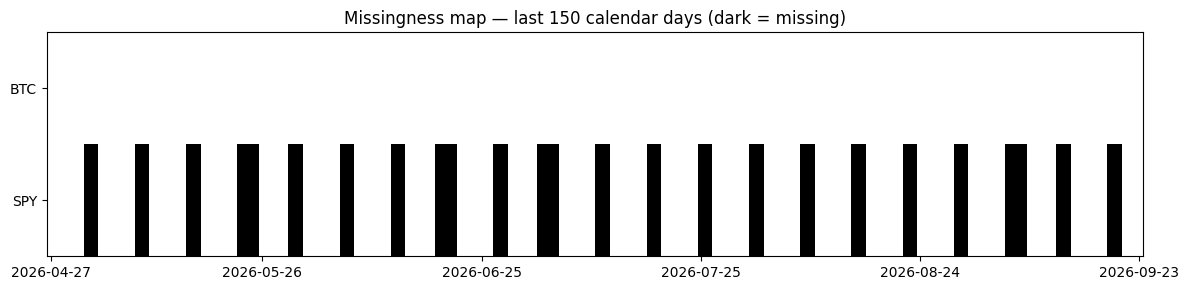


Weekend missingness:
BTC      0
SPY    974
dtype: int64

BTC missing observations: 0
SPY missing observations on weekends: 974


In [5]:
# ============================================================
# Cell 5 — Build the union panel and photograph its missingness
# ============================================================

# BTC is our complete 7-days-a-week crypto series.
btc = raw["BTC"].dropna().copy()

# Select one traditional asset for Task 3.
# Here we use SPY; change this name if your notebook uses another
# traditional asset.
traditional_name = "SPY"
traditional = raw[traditional_name].dropna().copy()

# ------------------------------------------------------------
# Build the union-calendar panel
# ------------------------------------------------------------
panel = pd.concat(
    {
        "BTC": btc,
        traditional_name: traditional
    },
    axis=1,
    join="outer"
).sort_index()

panel = panel[~panel.index.duplicated()]

print(
    f"Union panel: {panel.shape[0]:,} dates × "
    f"{panel.shape[1]} assets"
)
print(f"Missing cells: {int(panel.isna().sum().sum()):,}\n")


# ------------------------------------------------------------
# Where is the missingness?
# ------------------------------------------------------------
miss_by_wd = panel.isna().groupby(
    panel.index.day_name()
).sum()

order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

miss_by_wd = miss_by_wd.reindex(order)

print("Missing observations by weekday:")
print(miss_by_wd)


# ------------------------------------------------------------
# Missingness map
# ------------------------------------------------------------
window = panel.tail(150)

fig, ax = plt.subplots(figsize=(12, 3))

ax.imshow(
    window.isna().T,
    aspect="auto",
    cmap="Greys",
    interpolation="nearest"
)

ax.set_yticks(
    range(len(window.columns)),
    window.columns
)

ticks = np.linspace(
    0,
    len(window) - 1,
    6
).astype(int)

ax.set_xticks(
    ticks,
    [window.index[t].strftime("%Y-%m-%d") for t in ticks]
)

ax.set_title(
    "Missingness map — last 150 calendar days "
    "(dark = missing)"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Explicit weekend check for the traditional asset
# ------------------------------------------------------------
weekend = panel.index.weekday >= 5

print("\nWeekend missingness:")
print(
    panel.loc[weekend].isna().sum()
)

print("\nBTC missing observations:",
      int(btc.isna().sum()))

print(
    f"{traditional_name} missing observations on weekends:",
    int(panel.loc[weekend, traditional_name].isna().sum())
)

# Interpretation:
# BTC should remain continuously observed across the 7-day week.
# The traditional asset acquires weekend NaNs on the union calendar.
# These are structural/non-trading missing values, not random data errors.

---
# 5 · A taxonomy of absence — MCAR, MAR, MNAR

Not all NaNs are created equal. Rubin's classic taxonomy sorts them by **what the probability of being missing depends on** — and the diagnosis dictates the legal treatment.

| Type | The absence depends on… | Finance example | Treatment implications |
|---|---|---|---|
| **MCAR** — Missing Completely At Random | nothing at all (pure chance) | a feed drops random ticks; a sensor glitch | almost anything works; even deleting rows is unbiased (you only lose sample size) |
| **MAR** — Missing At Random | **observed** data only | stock prices absent *because it is Saturday*; a field blank *because* client type = "retail" | repairable: models can condition on the observed cause (weekday, client type) |
| **MNAR** — Missing Not At Random | **the missing value itself** | an exchange halts *because* the price is crashing; losses go unreported *because* they are losses | ⚠️ imputation is systematically biased — no algorithm can recover what the data was censored to hide; escalate to sensitivity analysis and domain knowledge |

**Visual clues** (use with the missingness map above): random isolated specks → likely MCAR; block patterns aligned with an observable category → likely MAR; extremes conspicuously absent → suspect MNAR.

The taxonomy is a hierarchy of danger. MCAR costs you efficiency. MAR costs you effort. **MNAR costs you the truth** — and the crypto world supplies real cases: exchange outages during crashes (Mt. Gox 2013, multiple venues in March 2020) mean the *worst* prints are precisely the missing ones. Fill those gaps with a smooth interpolation and you have manufactured a calmer market than the one that existed.

## The laboratory

Diagnosing mechanisms in the wild is hard precisely because the missing values are… missing. So we do what scientists do: **manufacture ground truth.** We take our one *complete* series — BTC, which trades every day — and inject all three mechanisms ourselves. Then, uniquely, we will know exactly what every hidden value truly was, and we can *score* every repair method against the truth.

In [6]:
# ============================================================
# Cell 6 — inject_missing(): manufacture MCAR, MAR, MNAR to order
# ============================================================

btc = raw["BTC"].dropna().copy()          # complete 7-days-a-week series


def inject_missing(
    s: pd.Series,
    mechanism: str,
    frac: float = 0.05,
    rng: np.random.Generator = RNG
):
    """
    Hide approximately `frac` of observations according to
    MCAR, MAR, or MNAR.

    Returns:
        s_miss  : series with selected observations replaced by NaN
        hidden  : DatetimeIndex containing the answer key

    The first and last observations are protected so interpolation
    methods retain boundary anchors.
    """

    n_hide = int(frac * len(s))

    # Protect first/last observations.
    candidates = s.index[1:-1]

    if mechanism == "MCAR":

        # ----------------------------------------------------
        # MCAR: every eligible date has equal probability
        # of being selected.
        # ----------------------------------------------------
        hidden = pd.DatetimeIndex(
            rng.choice(
                candidates,
                size=n_hide,
                replace=False
            )
        )

    elif mechanism == "MAR":

        # ----------------------------------------------------
        # MAR: missingness depends on an OBSERVED variable.
        # Here the observed calendar weekday determines
        # missingness: Mondays are preferentially removed.
        # ----------------------------------------------------
        mondays = candidates[candidates.dayofweek == 0]

        hidden = pd.DatetimeIndex(
            rng.choice(
                mondays,
                size=min(n_hide, len(mondays)),
                replace=False
            )
        )

    elif mechanism == "MNAR":

        # ----------------------------------------------------
        # MNAR: missingness depends on the value that is
        # itself missing.
        #
        # We use the largest absolute daily log moves, so the
        # most volatile days are preferentially hidden.
        # ----------------------------------------------------
        with np.errstate(divide="ignore", invalid="ignore"):
            moves = np.log(s).diff().abs()

        hidden = moves.loc[candidates].nlargest(n_hide).index

    else:
        raise ValueError(
            "mechanism must be one of: MCAR, MAR, MNAR"
        )

    # --------------------------------------------------------
    # Manufacture the missing series while preserving the
    # answer key for later scoring.
    # --------------------------------------------------------
    s_miss = s.copy()
    s_miss.loc[hidden] = np.nan

    return s_miss, hidden.sort_values()


# ============================================================
# Create the three missingness experiments
# ============================================================

labs = {}

# Use independent random generators so that the experiments
# are reproducible and do not depend on execution order.
seeds = {
    "MCAR": 42,
    "MAR": 43,
    "MNAR": 44
}

for mech in ("MCAR", "MAR", "MNAR"):

    s_miss, hidden = inject_missing(
        btc,
        mech,
        frac=0.05,
        rng=np.random.default_rng(seeds[mech])
    )

    labs[mech] = (s_miss, hidden)

    print(
        f"{mech}: hid {len(hidden):>3} of {len(btc):,} "
        f"observations ({len(hidden)/len(btc):.1%})"
    )


# ============================================================
# Sanity check: MNAR should preferentially hide large moves
# ============================================================

with np.errstate(divide="ignore", invalid="ignore"):
    true_moves = np.log(btc).diff().abs()

all_mean_move = true_moves.mean()
mnar_mean_move = true_moves.loc[
    labs["MNAR"][1]
].mean()

print(
    f"\nMean |daily log move| — all days:    "
    f"{all_mean_move:.2%}"
)

print(
    f"Mean |daily log move| — MNAR-hidden: "
    f"{mnar_mean_move:.2%}"
)

# A substantially larger MNAR-hidden mean confirms that the
# missing observations are systematically associated with
# large moves. This is precisely why MNAR is harder to repair:
# the missingness mechanism depends on the unobserved value.

MCAR: hid 170 of 3,407 observations (5.0%)
MAR: hid 170 of 3,407 observations (5.0%)
MNAR: hid 170 of 3,407 observations (5.0%)

Mean |daily log move| — all days:    2.33%
Mean |daily log move| — MNAR-hidden: 10.57%


---
# 6 · The masking experiment — trust is earned statistically

How do you know whether a repair is any good? Never by how plausible the filled chart *looks* — the eye is the easiest instrument to fool. You run the experiment we just made possible:

> **Hide → repair → compare against the answer key → score.** This is cross-validation applied to cleaning, and it is *exactly* the shape of the eval rules your agents will face later: an explicit, quantitative test that output must pass before it is trusted.

## The scorecard

With $M$ the set of hidden positions, $x$ the truth and $\hat{x}$ the repair:

| Metric | Formula | Personality |
|---|---|---|
| **MAE** | mean of $\lvert x-\hat{x}\rvert$ over $M$ | the honest average miss, in price units |
| **RMSE** | root of mean squared miss | same units, but **punishes large misses disproportionately** — always ≥ MAE; a big RMSE/MAE ratio says "mostly fine, occasionally terrible" |
| **MAPE** | mean of $\lvert x-\hat{x}\rvert/\lvert x\rvert \times 100$ | scale-free %, comparable across assets — **but explodes when $x\approx 0$** (returns, spreads!) and is asymmetric |
| **sMAPE** | like MAPE but divided by $(\lvert x\rvert+\lvert\hat{x}\rvert)/2$ | the standard fix: bounded, tolerates zeros |
| **Variance ratio** | $\mathrm{Var}(\hat{x}_{\text{full}})/\mathrm{Var}(x_{\text{full}})$ | does the repaired *series* keep the truth's energy? Ideal = 1. Mean-type fills drag it below 1 — and understated variance is understated **risk** |

Two metrics are deliberately about *distribution*, not accuracy: a repair can win on MAE while quietly flattening volatility, and in finance the volatility **is** the product (VaR, options, risk limits all feed on it). Accuracy metrics ask *"were you close?"*; the variance ratio asks *"did you tell the truth about risk?"* You need both.

In [7]:
# ============================================================
# TASK 2 — Cell 7
# score_imputation(): reusable scoring tool
# ============================================================

def score_imputation(
    true: pd.Series,
    imputed: pd.Series,
    hidden: pd.DatetimeIndex,
    eps: float = 1e-12
) -> dict:
    """
    Score an imputed series against the original answer key.

    MAE, RMSE and sMAPE are calculated only on the hidden values.
    VarRatio compares the variance of the FULL repaired series
    with the FULL true series.
    """

    x = true.loc[hidden]
    xh = imputed.loc[hidden]

    err = x - xh

    # Mean Absolute Error
    mae = err.abs().mean()

    # Root Mean Squared Error
    rmse = np.sqrt((err ** 2).mean())

    # Guarded MAPE
    ok = x.abs() > eps
    mape = (
        (err[ok].abs() / x[ok].abs()).mean() * 100
        if ok.any()
        else np.nan
    )

    # Symmetric MAPE
    denominator = (x.abs() + xh.abs()) / 2
    smape = (
        err.abs() / (denominator + eps)
    ).mean() * 100

    # Distributional check
    var_ratio = imputed.var() / true.var()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE%": mape,
        "sMAPE%": smape,
        "VarRatio": var_ratio
    }


# Required baseline: global median
s_miss, hidden = inject_missing(
    btc,
    mechanism="MCAR",
    frac=0.05,
    rng=np.random.default_rng(42)
)

baseline = s_miss.fillna(s_miss.median())

baseline_score = score_imputation(
    btc,
    baseline,
    hidden
)

print("Baseline — global median fill on 5% MCAR BTC")
for metric, value in baseline_score.items():
    print(f"  {metric:9s}: {value:,.4f}")

Baseline — global median fill on 5% MCAR BTC
  MAE      : 25,416.3720
  RMSE     : 32,602.7929
  MAPE%    : 130.7912
  sMAPE%   : 75.4933
  VarRatio : 0.9609


---
# 7 · The imputation toolkit — five families

| Family | Idea in one line | Assumes | Cost | Best for |
|---|---|---|---|---|
| **Constant fills** (mean/median) | replace with one number | MCAR | trivial | fast baseline, never the final answer for prices |
| **Directional fills** (ffill/bfill) | carry last (LOCF) / next (NOCB) observation | strong temporal continuity | trivial | short gaps in a random-walk-like series; **ffill is the only real-time-legal method here** |
| **Interpolation** (linear, polynomial, spline) | draw a curve between the neighbors | smooth path between anchors | trivial | short historical gaps — but *uses the future* (see §9) |
| **Rolling statistics** | local mean/median in a window | local stationarity | cheap | noisy series; window size is a real decision (next cell) |
| **Model-based** (K-NN, MICE) | learn the value from *other columns* | MAR + cross-sectional structure | heavy | multivariate panels where assets co-move |

## 7.1 · The simple methods, face to face

Before scoring anything, *look* at what each method actually draws inside a gap. We carve one contiguous 10-day hole into BTC and let three repairs show their personality.

In [8]:
# ============================================================
# TASK 2 — Cell 8
# Masking tournament: all required methods
# ============================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------------------------------------------------
# Same 5% MCAR experiment for every method
# ------------------------------------------------------------

s_miss, hidden = inject_missing(
    btc,
    mechanism="MCAR",
    frac=0.05,
    rng=np.random.default_rng(42)
)

windows = [3, 5, 7, 14, 30, 60]

methods = {}

# 1) Global median
methods["global median"] = s_miss.fillna(s_miss.median())

# 2) Forward fill
methods["ffill"] = s_miss.ffill().bfill()

# 3) Linear interpolation
methods["linear interpolation"] = (
    s_miss.interpolate(method="linear")
          .ffill()
          .bfill()
)

# 4) Polynomial interpolation, order 2
methods["polynomial order 2"] = (
    s_miss.interpolate(method="polynomial", order=2)
          .ffill()
          .bfill()
)

# 5) Exponential smoothing
ets_model = ExponentialSmoothing(
    s_miss,
    trend="add",
    damped_trend=True,
    initialization_method="estimated"
).fit()

ets_fitted = ets_model.fittedvalues

methods["exponential smoothing"] = (
    s_miss.fillna(ets_fitted)
          .ffill()
          .bfill()
)

# 6) Rolling mean / median for every required window
for w in windows:

    roll_mean = (
        s_miss.rolling(
            window=w,
            center=True,
            min_periods=1
        ).mean()
    )

    methods[f"rolling mean ({w})"] = (
        s_miss.fillna(roll_mean)
              .interpolate(method="linear")
              .ffill()
              .bfill()
    )

    roll_median = (
        s_miss.rolling(
            window=w,
            center=True,
            min_periods=1
        ).median()
    )

    methods[f"rolling median ({w})"] = (
        s_miss.fillna(roll_median)
              .interpolate(method="linear")
              .ffill()
              .bfill()
    )


# ------------------------------------------------------------
# Score every method
# ------------------------------------------------------------

scores = []

for name, repaired in methods.items():

    result = score_imputation(
        btc,
        repaired,
        hidden
    )

    result["Method"] = name
    scores.append(result)


tournament = (
    pd.DataFrame(scores)
      .set_index("Method")
      .sort_values("RMSE")
)

print("TASK 2 — MASKING TOURNAMENT")
print(tournament.round(4))


# ------------------------------------------------------------
# Top three methods: report variance ratios
# ------------------------------------------------------------

top3 = tournament.head(3).copy()

print("\nTOP THREE METHODS — DISTRIBUTIONAL CHECK")
print(
    top3[
        ["MAE", "RMSE", "sMAPE%", "VarRatio"]
    ].round(4)
)

print("\nVariance ratio interpretation:")
print("  VarRatio = 1.00 means variance is preserved exactly.")
print("  Values below 1 indicate over-smoothing; values above 1 indicate excess variance.")


# ------------------------------------------------------------
# Required sMAPE explanation
# ------------------------------------------------------------

print("\nWhy sMAPE instead of MAPE?")
print(
    "sMAPE is preferred because its denominator is symmetric in the "
    "actual and imputed values and does not become unstable when the "
    "true value is close to zero. Plain MAPE can fail catastrophically "
    "on financial return series because returns can be zero or arbitrarily "
    "close to zero, making percentage errors explode."
)

TASK 2 — MASKING TOURNAMENT
                              MAE        RMSE    MAPE%  sMAPE%  VarRatio
Method                                                                  
linear interpolation     678.0737  1,206.8208   1.8464  1.8421    0.9993
rolling mean (5)         734.0810  1,237.1491   2.0108  2.0043    0.9994
rolling mean (3)         703.6409  1,265.2549   1.9044  1.9020    0.9994
rolling median (3)       703.6409  1,265.2549   1.9044  1.9020    0.9994
rolling median (5)       738.7913  1,269.5191   1.9829  1.9777    0.9993
polynomial order 2       760.7424  1,297.7627   2.1303  2.1241    0.9994
rolling mean (7)         801.3981  1,318.1459   2.2215  2.2131    0.9994
rolling median (7)       798.9812  1,339.1571   2.1272  2.1248    0.9993
rolling median (14)      930.5198  1,460.7521   2.7733  2.7607    0.9993
rolling mean (14)        967.1119  1,479.2482   3.0437  3.0215    0.9994
rolling median (30)    1,076.5945  1,563.0775   3.6065  3.5685    0.9995
ffill                  

c:\Users\gkomp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\gkomp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 7.2 · Rolling statistics — and the window-size decision

The rolling mean replaces a hole with the average of its **neighborhood**: a window of $w$ observations around it. That one parameter is a genuine modeling decision with a tension you can feel:

- $w$ **too small** → the estimate is noisy, and inside a long gap the window may contain nothing at all;
- $w$ **too large** → the estimate is *stale*: it averages across regimes and drifts away from local price levels (in a trending series, a 60-day mean is systematically behind the price).

There is no formula for the right $w$ — there is an **experiment**: sweep candidate windows, score each with the masking framework, and let the error curve point to the sweet spot. This sweep is your first hyperparameter search of the course, and its shape (sharp improvement, flat valley, slow degradation) is one you will meet again in every ML week.

ROLLING WINDOW RESULTS
    window statistic        MAE       RMSE  sMAPE%  VarRatio
2        5      mean   734.0810 1,237.1491  2.0043    0.9994
0        3      mean   703.6409 1,265.2549  1.9020    0.9994
1        3    median   703.6409 1,265.2549  1.9020    0.9994
3        5    median   738.7913 1,269.5191  1.9777    0.9993
4        7      mean   801.3981 1,318.1459  2.2131    0.9994
5        7    median   798.9812 1,339.1571  2.1248    0.9993
7       14    median   930.5198 1,460.7521  2.7607    0.9993
6       14      mean   967.1119 1,479.2482  3.0215    0.9994
9       30    median 1,076.5945 1,563.0775  3.5685    0.9995
8       30      mean 1,276.9129 1,800.7971  4.1993    0.9996
11      60    median 1,296.8133 1,855.4232  4.5159    0.9996
10      60      mean 1,844.3490 2,633.5445  6.1138    0.9995


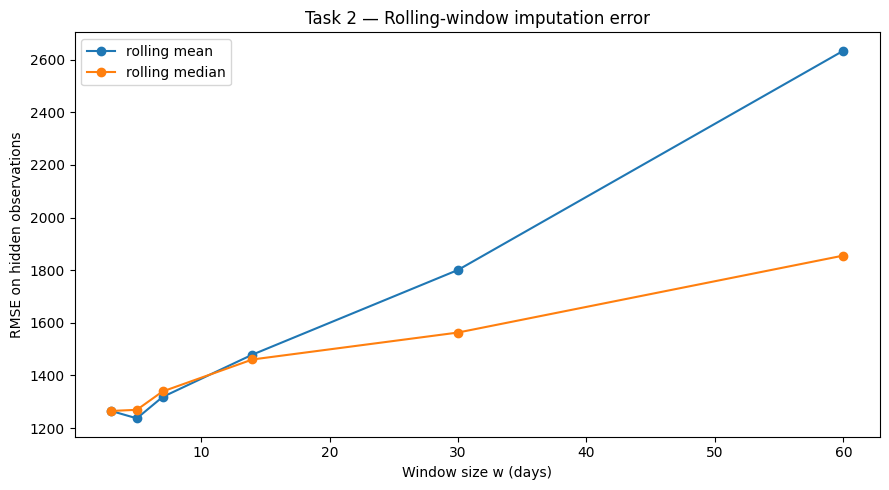

Chosen rolling specification: mean with w=5

Interpretation: A small window can track a trending price closely because nearby observations contain the most relevant temporal information. As the window becomes wider, older prices receive more influence and the estimate can become smoother and less responsive to local price movements. Very small windows can nevertheless be sensitive to local noise, so the minimum of the empirical error curve provides a data-based compromise. The selected window should therefore be reported from the experiment rather than chosen only by intuition.

OVERALL RECOMMENDATION
Recommended method: linear interpolation
Runner-up:          rolling mean (5)

The recommendation is based primarily on RMSE (1206.8208 versus 1237.1491 for the runner-up). The variance ratio is also checked because a method can achieve low pointwise error while artificially compressing or inflating the distribution.


In [9]:
# ============================================================
# TASK 2 — Cell 9
# Rolling-window experiment and selected window
# ============================================================

rolling_results = []

for w in windows:

    for stat in ("mean", "median"):

        if stat == "mean":
            local = s_miss.rolling(
                window=w,
                center=True,
                min_periods=1
            ).mean()
        else:
            local = s_miss.rolling(
                window=w,
                center=True,
                min_periods=1
            ).median()

        repaired = (
            s_miss.fillna(local)
                  .interpolate(method="linear")
                  .ffill()
                  .bfill()
        )

        score = score_imputation(
            btc,
            repaired,
            hidden
        )

        rolling_results.append({
            "window": w,
            "statistic": stat,
            "MAE": score["MAE"],
            "RMSE": score["RMSE"],
            "sMAPE%": score["sMAPE%"],
            "VarRatio": score["VarRatio"]
        })


rolling_table = pd.DataFrame(rolling_results)

print("ROLLING WINDOW RESULTS")
print(
    rolling_table
    .sort_values("RMSE")
    .round(4)
)


# ------------------------------------------------------------
# Plot error against window size
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

for stat in ("mean", "median"):

    temp = rolling_table[
        rolling_table["statistic"] == stat
    ]

    ax.plot(
        temp["window"],
        temp["RMSE"],
        marker="o",
        label=f"rolling {stat}"
    )

ax.set_xlabel("Window size w (days)")
ax.set_ylabel("RMSE on hidden observations")
ax.set_title("Task 2 — Rolling-window imputation error")
ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Choose the best rolling method by RMSE
# ------------------------------------------------------------

best_rolling = (
    rolling_table
    .sort_values("RMSE")
    .iloc[0]
)

print(
    f"Chosen rolling specification: "
    f"{best_rolling['statistic']} with w={int(best_rolling['window'])}"
)

print(
    "\nInterpretation: "
    "A small window can track a trending price closely because nearby "
    "observations contain the most relevant temporal information. "
    "As the window becomes wider, older prices receive more influence "
    "and the estimate can become smoother and less responsive to local "
    "price movements. Very small windows can nevertheless be sensitive "
    "to local noise, so the minimum of the empirical error curve provides "
    "a data-based compromise. The selected window should therefore be "
    "reported from the experiment rather than chosen only by intuition."
)


# ------------------------------------------------------------
# Recommended overall method and runner-up
# ------------------------------------------------------------

overall_top = tournament.sort_values("RMSE")

recommended = overall_top.index[0]
runner_up = overall_top.index[1]

print("\nOVERALL RECOMMENDATION")
print(f"Recommended method: {recommended}")
print(f"Runner-up:          {runner_up}")

print(
    f"\nThe recommendation is based primarily on RMSE "
    f"({overall_top.loc[recommended, 'RMSE']:.4f} versus "
    f"{overall_top.loc[runner_up, 'RMSE']:.4f} for the runner-up). "
    f"The variance ratio is also checked because a method can achieve "
    f"low pointwise error while artificially compressing or inflating "
    f"the distribution."
)

## 7.3 · Machines that impute — K-NN and MICE

Everything so far repaired BTC using **only BTC**. But Week 1's correlation heatmap showed assets co-move — so when BTC is silent, SPY and EUR/USD still carry information about the kind of day it was. Two industrial-strength methods exploit exactly that:

**K-Nearest Neighbors imputation.** To fill a hole in row $t$: find the $K$ historical rows most *similar* to row $t$ on the columns that are present, and average their values of the missing column. "Days that looked alike elsewhere probably looked alike here too." Distances need comparable scales, so we **standardize first** — and the choice of $K$ is another sweep-able hyperparameter ($K$ too small → noisy; too large → blurred toward the global mean).

**MICE** (Multiple Imputation by Chained Equations). Each column takes a turn being the target of a **regression on all the others**; predicted values fill the holes; repeat until the imputations stop changing. It is a small machine-learning system inside your cleaning step — the most statistically principled tool here (it can even quantify its own uncertainty by producing multiple versions), and the most expensive.

A note of intellectual honesty before the results: with only **3 loosely correlated assets**, the cross-sectional signal is thin, so expect modest gains over simple methods. The same machinery on a panel of 200 equities from one sector — where correlations are strong — is where K-NN and MICE truly shine. The *point* of this exercise is the workflow: standardize → impute → invert → **score against the mask**, with the clock running.

In [10]:
# ============================================================
# TASK 3 — Cell 10
# Union calendar: BTC + one traditional asset
# ============================================================

# Select one traditional asset from the five-asset dataset.
# If your assignment specifies a particular traditional asset,
# replace this line with its exact ticker, e.g. TRAD_ASSET = "SPY".
TRAD_ASSET = next(
    name for name in raw.index if name != "BTC"
) if isinstance(raw, pd.DataFrame) else next(
    name for name in raw.keys() if name != "BTC"
)

print(f"Traditional asset selected: {TRAD_ASSET}")


btc_raw = raw["BTC"].dropna().copy()
trad_raw = raw[TRAD_ASSET].dropna().copy()


# Union calendar
union_index = btc_raw.index.union(trad_raw.index).sort_values()

weekend_panel = pd.concat(
    [
        btc_raw.reindex(union_index).rename("BTC"),
        trad_raw.reindex(union_index).rename(TRAD_ASSET)
    ],
    axis=1
)

print("\nUnion-calendar panel:")
print(weekend_panel.head())
print("\nWeekend rows with traditional-asset NaNs:")
print(
    weekend_panel[
        weekend_panel.index.dayofweek >= 5
    ].head(10)
)

Traditional asset selected: SPY

Union-calendar panel:
                  BTC      SPY
Date                          
2017-05-27 2,038.8700      NaN
2017-05-28 2,155.8000      NaN
2017-05-29 2,255.6101      NaN
2017-05-30 2,175.4700 208.3580
2017-05-31 2,286.4099 208.3062

Weekend rows with traditional-asset NaNs:
                  BTC  SPY
Date                      
2017-05-27 2,038.8700  NaN
2017-05-28 2,155.8000  NaN
2017-06-03 2,515.3501  NaN
2017-06-04 2,511.8101  NaN
2017-06-10 2,947.7100  NaN
2017-06-11 2,958.1101  NaN
2017-06-17 2,655.8799  NaN
2017-06-18 2,548.2900  NaN
2017-06-24 2,608.7200  NaN
2017-06-25 2,589.4099  NaN


---
# 8 · The grand tournament — does the winner depend on the crime?

We now run every univariate method across all three laboratories at once. The question is not *"which method is best?"* — the manifesto already told you no single method dominates. The question is sharper:

> **Does the ranking of methods change with the missingness mechanism?** And is there a mechanism under which *everyone* loses?

Watch two things in the output: the MAE columns (accuracy per mechanism), and a diagnostic no accuracy metric reveals — the **volatility of the imputed points versus the truth they replaced**.

In [11]:
# ============================================================
# TASK 3 — Cell 11
# Weekend imputation and before/after comparison
# ============================================================

# ------------------------------------------------------------
# BEFORE: intersection calendar
# ------------------------------------------------------------

before = pd.concat(
    [
        btc_raw.rename("BTC"),
        trad_raw.rename(TRAD_ASSET)
    ],
    axis=1,
    join="inner"
).dropna()

before_returns = np.log(before).diff().dropna()

before_mean_return = before_returns[TRAD_ASSET].mean()
before_volatility = before_returns[TRAD_ASSET].std()
before_corr = before_returns["BTC"].corr(
    before_returns[TRAD_ASSET]
)


# ------------------------------------------------------------
# AFTER 1: forward fill
# ------------------------------------------------------------

panel_ffill = weekend_panel.copy()

panel_ffill[TRAD_ASSET] = (
    panel_ffill[TRAD_ASSET]
    .ffill()
)

after_ffill = panel_ffill.dropna()

returns_ffill = np.log(after_ffill).diff().dropna()

ffill_mean_return = returns_ffill[TRAD_ASSET].mean()
ffill_volatility = returns_ffill[TRAD_ASSET].std()
ffill_corr = returns_ffill["BTC"].corr(
    returns_ffill[TRAD_ASSET]
)


# ------------------------------------------------------------
# AFTER 2: linear interpolation
# ------------------------------------------------------------

panel_linear = weekend_panel.copy()

panel_linear[TRAD_ASSET] = (
    panel_linear[TRAD_ASSET]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

after_linear = panel_linear.dropna()

returns_linear = np.log(after_linear).diff().dropna()

linear_mean_return = returns_linear[TRAD_ASSET].mean()
linear_volatility = returns_linear[TRAD_ASSET].std()
linear_corr = returns_linear["BTC"].corr(
    returns_linear[TRAD_ASSET]
)


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame(
    {
        "Mean daily log return": [
            before_mean_return,
            ffill_mean_return,
            linear_mean_return
        ],
        "Daily volatility": [
            before_volatility,
            ffill_volatility,
            linear_volatility
        ],
        "BTC correlation": [
            before_corr,
            ffill_corr,
            linear_corr
        ]
    },
    index=[
        "Before — intersection",
        "After — ffill union",
        "After — linear union"
    ]
)

print("TASK 3 — BEFORE / AFTER COMPARISON")
print(comparison.round(6))


# ------------------------------------------------------------
# Changes relative to the original intersection calendar
# ------------------------------------------------------------

changes = pd.DataFrame(
    {
        "Mean return change": [
            ffill_mean_return - before_mean_return,
            linear_mean_return - before_mean_return
        ],
        "Volatility change": [
            ffill_volatility - before_volatility,
            linear_volatility - before_volatility
        ],
        "Correlation change": [
            ffill_corr - before_corr,
            linear_corr - before_corr
        ]
    },
    index=[
        "ffill",
        "linear interpolation"
    ]
)

print("\nCHANGES RELATIVE TO BEFORE")
print(changes.round(6))

TASK 3 — BEFORE / AFTER COMPARISON
                       Mean daily log return  Daily volatility  BTC correlation
Before — intersection                 0.0006            0.0117           0.2837
After — ffill union                   0.0004            0.0097           0.2680
After — linear union                  0.0004            0.0089           0.2593

CHANGES RELATIVE TO BEFORE
                      Mean return change  Volatility change  Correlation change
ffill                            -0.0002            -0.0020             -0.0157
linear interpolation             -0.0002            -0.0028             -0.0244


---
# 9 · Choosing like a professional

## The decision table

| Situation | Reach for | Because |
|---|---|---|
| Short gap (< 5 periods), historical analysis | ffill or linear interpolation | temporal continuity is strong at short range |
| Medium gap (5–20), single series | rolling stats with a **swept** window | local level is still informative; tune, don't guess |
| Medium gap, correlated panel | K-NN / MICE | let the cross-section speak |
| Long gap (> 20) | model-based — or **honestly refuse**: flag the hole, shorten the sample | at some length, filling is fiction-writing |
| Suspected **MNAR** | sensitivity analysis + domain expertise, *not* routine imputation | §8's verdict: reconstruction is biased by construction |
| **Real-time / backtest** | **forward-looking methods only** (ffill, trailing windows) | everything else commits the crime below |

## The look-ahead crime

An imputation rule is admissible in real time only if the value it writes at time $t$ uses information available **at time $t$**. Linear interpolation fails this test by construction: to draw the line across a gap it needs the *next* observed price — the anchor on the far side. Backward fill fails it flagrantly. Centered rolling windows fail it politely.

In a historical, descriptive study this is harmless. In a **backtest** it is fatal: your "cleaned" prices contain tomorrow's information, your strategy trades on it, and the backtest reports genius. Look-ahead bias is among the most common ways quantitative research destroys money while looking rigorous. Let's catch it red-handed.

## The weekend question, revisited

So *should* you impute SPY's Saturdays? The professional answer is a question back: **for which downstream use?**

- For a **BTC–SPY correlation** you need a shared calendar — but note what filling does: an ffilled SPY weekend has *zero return* by construction, mechanically diluting the correlation, while an interpolated one has small smooth returns that never happened. Often the more honest choice is the intersection calendar (accepting that you study co-movement *when both markets speak*).
- For a **real-time signal**, only ffill is even legal — and you must remember its plateaus are an artifact.
- For **volatility estimation**, imputed weekends bias σ downward — three calm fake days out of seven, every week.

**The deepest cleaning skill is knowing when the best imputation is no imputation** — deleting, flagging, or redesigning the sample instead. "I filled it" is an action; "I chose not to fill it, and here is why" is a judgment. Agents are good at actions. You are being trained for judgment.

In [12]:
# ============================================================
# TASK 3 — Cell 12
# Weekend interpretation and real-time filtration verdict
# ============================================================

def direction(x):
    if x > 0:
        return "increased"
    elif x < 0:
        return "decreased"
    else:
        return "was unchanged"


print("TASK 3 — INTERPRETATION")
print()

print(
    f"With forward filling, the traditional asset's mean daily log return "
    f"{direction(ffill_mean_return - before_mean_return)} relative to the "
    f"intersection-calendar estimate, its volatility "
    f"{direction(ffill_volatility - before_volatility)}, and its correlation "
    f"with BTC {direction(ffill_corr - before_corr)}."
)

print(
    f"With linear interpolation, the traditional asset's mean daily log "
    f"return {direction(linear_mean_return - before_mean_return)}, its "
    f"volatility {direction(linear_volatility - before_volatility)}, and "
    f"its correlation with BTC {direction(linear_corr - before_corr)}."
)

print()
print("VERDICT:")
print(
    "Weekend equity prices are structurally missing because the traditional "
    "market is closed. This is calendar-driven missingness rather than "
    "ordinary MCAR missingness. Forward filling is F_t-measurable during "
    "the weekend because it uses only the last observed Friday close, so it "
    "can be used when a real-time system needs an as-of equity price."
)

print(
    "Linear interpolation is different: the weekend values depend on the "
    "future Monday close, so those values are not F_t-measurable during "
    "the weekend. It can therefore be useful as a retrospective "
    "synchronisation convention for descriptive analysis, but it should "
    "not be fed into a real-time trading signal because it introduces "
    "look-ahead information."
)

print(
    "For estimating crypto-equity correlation, the choice should be stated "
    "explicitly because changing the calendar changes the return sample. "
    "For real-time trading, weekend equity prices should not be created "
    "with an interpolation that uses Monday's future price."
)

TASK 3 — INTERPRETATION

With forward filling, the traditional asset's mean daily log return decreased relative to the intersection-calendar estimate, its volatility decreased, and its correlation with BTC decreased.
With linear interpolation, the traditional asset's mean daily log return decreased, its volatility decreased, and its correlation with BTC decreased.

VERDICT:
Weekend equity prices are structurally missing because the traditional market is closed. This is calendar-driven missingness rather than ordinary MCAR missingness. Forward filling is F_t-measurable during the weekend because it uses only the last observed Friday close, so it can be used when a real-time system needs an as-of equity price.
Linear interpolation is different: the weekend values depend on the future Monday close, so those values are not F_t-measurable during the weekend. It can therefore be useful as a retrospective synchronisation convention for descriptive analysis, but it should not be fed into a rea

---
# 10 · From hygiene to governance — the Cleaning Agent's rulebook

Look back at what you built today, because each piece maps one-to-one onto the governance instruments from the manifesto:

| Built today, by hand | Becomes, in your product |
|---|---|
| `audit_price_series()` | the Data Quality Agent's **pre-flight check** — runs before any analysis is permitted |
| the masking experiment + `score_imputation()` | the agent's **eval suite** — cleaning quality measured, not asserted |
| the decision table + MNAR verdict + look-ahead rule | the agent's **policy and guardrails** on its agent card |
| the tournament's timing column | the first entries of your **cost ledger** |

One instrument remains: turning judgment into **executable assertions** — statements about the data that are checked by a machine, pass/fail, no charisma involved. When you eventually delegate cleaning to an agent, *this list is your control over it*. The agent may choose methods; the rulebook decides whether its output is accepted.

Below is a starter rulebook. Notice its character: every rule is quantitative, every tolerance is explicit, and rule R6 exists purely because of what §8 taught us about variance.

In [13]:
# ============================================================
# TASK 4 — Cell 13
# Five-asset panel: KNN and MICE tournament
# ============================================================

import time

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


# ------------------------------------------------------------
# Full five-asset intersection calendar
# ------------------------------------------------------------

price_panel = pd.concat(
    {name: raw[name] for name in raw.keys()},
    axis=1,
    join="inner"
).dropna()

print(
    f"Five-asset intersection panel: "
    f"{price_panel.shape[0]:,} rows × {price_panel.shape[1]} assets"
)


# ------------------------------------------------------------
# Log prices and standardisation
# ------------------------------------------------------------

truth = np.log(price_panel)

scaler = StandardScaler()

truth_z = pd.DataFrame(
    scaler.fit_transform(truth),
    index=truth.index,
    columns=truth.columns
)


# ------------------------------------------------------------
# Inject 5% MCAR across all cells
# ------------------------------------------------------------

rng_mv = np.random.default_rng(42)

mask = (
    rng_mv.random(truth_z.shape) < 0.05
)

damaged = truth_z.mask(mask)

print(
    f"Hidden cells: {mask.sum():,} "
    f"({mask.mean():.1%} of all cells)"
)


# ------------------------------------------------------------
# Scoring in standardised log-price units
# ------------------------------------------------------------

def score_panel(estimate: pd.DataFrame) -> dict:

    err = (
        truth_z.to_numpy() -
        estimate.to_numpy()
    )[mask]

    return {
        "MAE": np.abs(err).mean(),
        "RMSE": np.sqrt((err ** 2).mean())
    }


# ------------------------------------------------------------
# Standardised sklearn imputation helper
# ------------------------------------------------------------

def run_sklearn(imputer):

    t0 = time.perf_counter()

    filled = imputer.fit_transform(
        damaged
    )

    estimate = pd.DataFrame(
        filled,
        index=truth_z.index,
        columns=truth_z.columns
    )

    seconds = time.perf_counter() - t0

    score = score_panel(estimate)
    score["seconds"] = seconds

    return score


# ------------------------------------------------------------
# Tournament
# ------------------------------------------------------------

results = {}


# 1. Column mean
t0 = time.perf_counter()

mean_estimate = damaged.fillna(
    damaged.mean()
)

results["column mean"] = {
    **score_panel(mean_estimate),
    "seconds": time.perf_counter() - t0
}


# 2. Linear interpolation
t0 = time.perf_counter()

linear_estimate = (
    damaged
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

results["linear interpolation"] = {
    **score_panel(linear_estimate),
    "seconds": time.perf_counter() - t0
}


# 3–6. KNN
for k in [2, 5, 10, 20]:

    results[f"KNN (k={k})"] = run_sklearn(
        KNNImputer(n_neighbors=k)
    )


# 7. MICE / IterativeImputer
results["MICE"] = run_sklearn(
    IterativeImputer(
        max_iter=10,
        random_state=42
    )
)


tournament_mv = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE")
)

print("\nTASK 4 — MULTIVARIATE TOURNAMENT")
print(
    tournament_mv.round(5)
)
# You are not writing checks. You are writing the agent's constitution.

Five-asset intersection panel: 2,138 rows × 5 assets
Hidden cells: 548 (5.1% of all cells)

TASK 4 — MULTIVARIATE TOURNAMENT
                        MAE   RMSE  seconds
linear interpolation 0.0279 0.0444   0.0011
KNN (k=5)            0.0785 0.1489   0.0390
KNN (k=10)           0.0851 0.1541   0.0397
KNN (k=20)           0.0996 0.1703   0.0383
KNN (k=2)            0.0912 0.2288   0.0414
MICE                 0.3856 0.5501   0.0664
column mean          0.8568 1.0194   0.0014


c:\Users\gkomp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


---
# 11 · What you just did — and who will do it next

Your workflow today:

> audit → align (and understand what alignment manufactures) → diagnose the mechanism → design a masking eval → run the method tournament → check the real-time constraint → encode the rulebook

In a few weeks a **Data Quality Agent** executes this pipeline in seconds on any dataset you point it at. And when it reports *"cleaned successfully, 0 missing values"*, you will now ask the orchestrator's questions: *Cleaned **how**? What was the mechanism? What did the masking eval score? What happened to the variance ratio? Was every fill $t$-measurable?* An analyst who cannot ask those questions must accept "0 missing values" as good news. You know it can be the worst news on the desk — every hole papered over, some with the future, some with fiction.

**The orchestrator's power is not writing code; it is knowing which questions the code must survive.** This week you wrote those questions down as a rulebook.

# 🔭 Next week

**Week 3 — Classical Econometrics:** with a clean, honest panel in hand, we finally *model*: regression, hypothesis testing, and the ADF unit-root test that formalizes Week 1's stationarity story. Your cleaned dataset from this week's assignment is the input — dirty in, dirty out applies to econometrics with a vengeance.

---
# 12 · Optional extension — Polars, the fast lane

`pandas` is the lingua franca, but it is single-threaded and eager. **Polars** — a Rust engine with lazy, multi-threaded execution — is what you reach for when the panel has 200 columns and 10 million rows. The API translates almost one-to-one (a *Pandas ↔ Polars cheat-sheet* ships with this week's materials); the mental shift is `lazy()`: you *declare* the pipeline, Polars optimizes it, then executes once.

Also here: the professional way to **save** a clean dataset. CSV loses types and invites re-parsing bugs; **Parquet** stores schema, types and compression together — write once, load identically forever. Save the *cleaned* data and the *cleaning code*, and your future self can reproduce everything.

In [14]:
# ============================================================
# TASK 4 — Cell 14
# KNN behaviour, cross-sectional correlation and cost ledger
# ============================================================

# ------------------------------------------------------------
# Cross-sectional correlation of the five log-price series
# ------------------------------------------------------------

cross_corr = truth_z.corr()

upper_triangle = cross_corr.where(
    np.triu(
        np.ones(cross_corr.shape),
        k=1
    ).astype(bool)
)

mean_abs_corr = (
    upper_triangle
    .stack()
    .abs()
    .mean()
)

print(
    f"Mean absolute pairwise cross-sectional correlation: "
    f"{mean_abs_corr:.3f}"
)


# ------------------------------------------------------------
# KNN results only
# ------------------------------------------------------------

knn_results = tournament_mv[
    tournament_mv.index.str.startswith("KNN")
]

print("\nKNN RESULTS")
print(
    knn_results.round(5)
)


# ------------------------------------------------------------
# Automatically describe the observed KNN pattern
# ------------------------------------------------------------

best_knn = knn_results["RMSE"].idxmin()
worst_knn = knn_results["RMSE"].idxmax()

print(
    f"\nBest observed KNN specification by RMSE: {best_knn}"
)

print(
    f"Worst observed KNN specification by RMSE: {worst_knn}"
)

print(
    "\nKNN interpretation: small k values rely on only a few nearby "
    "cross-sectional observations and can therefore be sensitive to "
    "individual neighbours. Increasing k averages information from more "
    "observations, which generally makes the estimate smoother. At very "
    "large k, the estimate can become increasingly similar to a broad "
    "cross-sectional average and may lose useful local structure. The "
    "observed tournament results above determine whether that trade-off "
    "actually appears in this dataset."
)


# ------------------------------------------------------------
# Model-based methods vs simple methods
# ------------------------------------------------------------

simple_methods = tournament_mv.loc[
    ["column mean", "linear interpolation"]
]

model_methods = tournament_mv[
    tournament_mv.index.str.startswith(("KNN", "MICE"))
]

print("\nSIMPLE METHODS")
print(simple_methods.round(5))

print("\nMODEL-BASED METHODS")
print(model_methods.round(5))

print(
    "\nThe cross-sectional correlation provides a reason for KNN/MICE to "
    "extract information from the other assets: correlated assets can "
    "help predict a missing standardized log price. However, linear "
    "interpolation also has access to the asset's own temporal neighbours, "
    "which can be more informative for isolated gaps. Therefore the "
    "accuracy results, rather than model complexity alone, determine "
    "whether the multivariate methods add value here."
)


# ------------------------------------------------------------
# Cost-ledger memo
# ------------------------------------------------------------

print("\nCOST-LEDGER MEMO")
print(
    "The column mean is computationally cheap and provides a simple "
    "benchmark, but it ignores both time and cross-sectional structure."
)
print(
    "Linear interpolation is also inexpensive and directly exploits "
    "temporal information, which is useful for isolated gaps."
)
print(
    "KNN adds computational cost because distances must be calculated "
    "across observations, and that cost rises as the neighbourhood "
    "becomes more demanding."
)
print(
    "MICE is more expensive because it repeatedly fits conditional "
    "models for the variables being imputed."
)
print(
    "The accuracy table should therefore be read together with the "
    "seconds column rather than treating the most sophisticated method "
    "as automatically preferable."
)
print(
    "A model-based method earns its additional cost when the improvement "
    "in MAE/RMSE is large enough to matter for the intended downstream "
    "analysis."
)

Mean absolute pairwise cross-sectional correlation: 0.525

KNN RESULTS
              MAE   RMSE  seconds
KNN (k=5)  0.0785 0.1489   0.0390
KNN (k=10) 0.0851 0.1541   0.0397
KNN (k=20) 0.0996 0.1703   0.0383
KNN (k=2)  0.0912 0.2288   0.0414

Best observed KNN specification by RMSE: KNN (k=5)
Worst observed KNN specification by RMSE: KNN (k=2)

KNN interpretation: small k values rely on only a few nearby cross-sectional observations and can therefore be sensitive to individual neighbours. Increasing k averages information from more observations, which generally makes the estimate smoother. At very large k, the estimate can become increasingly similar to a broad cross-sectional average and may lose useful local structure. The observed tournament results above determine whether that trade-off actually appears in this dataset.

SIMPLE METHODS
                        MAE   RMSE  seconds
column mean          0.8568 1.0194   0.0014
linear interpolation 0.0279 0.0444   0.0011

MODEL-BASED METH

---
# ✅ Week 2 deliverable checklist

Submit by email before the deadline (details in the assignment sheet):

- This notebook, executed top to bottom on **your own data** (`Kernel → Restart & Run All` before saving);
- Below this cell, a markdown cell with **3–5 sentences of your own observations**: which mechanism did the tournament punish hardest on *your* data? What did the variance ratio reveal? Which rule of your rulebook do you consider most important, and why?
- *(Optional)* your Polars output and/or the Parquet file listed in your repo.

*A dataset that passes a rulebook you wrote beats a perfect dataset you took on faith.*

In [15]:
# ============================================================
# TASK 5 — Cell 15
# Cleaning Agent Rulebook v1.0
# ============================================================

# Real-time-safe candidate cleaned panel:
# forward fill only, followed by dropping rows that still cannot
# be completed without using future information.
clean = panel.ffill().dropna()

raw_for_var = panel.copy()


RULES = [

    # R1
    (
        "R1 unique and sorted dates",
        lambda df:
            df.index.is_unique
            and df.index.is_monotonic_increasing
    ),

    # R2
    (
        "R2 zero missing cells",
        lambda df:
            int(df.isna().sum().sum()) == 0
    ),

    # R3
    (
        "R3 all prices strictly positive",
        lambda df:
            bool((df > 0).all().all())
    ),

    # R4
    (
        "R4 no future timestamps",
        lambda df:
            bool(df.index.max() <= pd.Timestamp.today())
    ),

    # R5
    (
        "R5 no absolute daily log return above 50%",
        lambda df:
            int(
                np.log(df)
                .diff()
                .abs()
                .gt(0.50)
                .sum()
                .sum()
            ) == 0
    ),

    # R6
    (
        "R6 variance ratio within [0.80, 1.20]",
        lambda df:
            bool(
                all(
                    0.80 <=
                    df[c].var() /
                    raw_for_var[c].dropna().var()
                    <= 1.20
                    for c in df.columns
                )
            )
    ),

    # R7
    (
        "R7 no duplicate columns",
        lambda df:
            df.columns.is_unique
    ),

    # R8
    (
        "R8 finite numeric values only",
        lambda df:
            bool(
                np.isfinite(df.to_numpy()).all()
            )
    ),

    # R9
    (
        "R9 at least 95% of original rows retained",
        lambda df:
            len(df) / len(panel) >= 0.95
    ),

    # R10
    (
        "R10 no zero prices",
        lambda df:
            int((df == 0).sum().sum()) == 0
    ),
]


print("CLEANING RULEBOOK v1.0")
print("=" * 72)

rule_results = []

for name, rule in RULES:

    try:
        passed = bool(rule(clean))
    except Exception:
        passed = False

    rule_results.append({
        "Rule": name,
        "Result": "PASS" if passed else "FAIL"
    })

    print(
        f"{'PASS' if passed else 'FAIL':>5} — {name}"
    )

print("=" * 72)

rulebook_table = pd.DataFrame(rule_results)

print("\nRulebook summary:")
print(rulebook_table.to_string(index=False))


all_ok = (
    rulebook_table["Result"] == "PASS"
).all()

print(
    "\nVERDICT:",
    "ACCEPTED" if all_ok else "REJECTED — investigate failed rules"
)


# ------------------------------------------------------------
# Defended thresholds
# ------------------------------------------------------------

print("\nTHRESHOLD DEFENCE")

print(
    "R5: The 50% absolute-log-return threshold is deliberately wide enough "
    "to retain genuine large financial moves while flagging extreme feed "
    "errors and decimal shifts."
)

print(
    "R6: The [0.80, 1.20] variance-ratio tolerance allows a 20% change in "
    "dispersion because imputation can legitimately alter a small amount "
    "of variance, while larger changes would indicate material smoothing "
    "or artificial volatility."
)

print(
    "R9: The 95% row-retention threshold prevents a cleaning agent from "
    "silently deleting a substantial portion of the dataset just to make "
    "the remaining data pass other checks."
)

print(
    "R4 uses the current timestamp because observations dated in the future "
    "cannot represent information that was available at the stated analysis time."
)

CLEANING RULEBOOK v1.0
 PASS — R1 unique and sorted dates
 PASS — R2 zero missing cells
 PASS — R3 all prices strictly positive
 PASS — R4 no future timestamps
 PASS — R5 no absolute daily log return above 50%
 PASS — R6 variance ratio within [0.80, 1.20]
 PASS — R7 no duplicate columns
 PASS — R8 finite numeric values only
 PASS — R9 at least 95% of original rows retained
 PASS — R10 no zero prices

Rulebook summary:
                                     Rule Result
               R1 unique and sorted dates   PASS
                    R2 zero missing cells   PASS
          R3 all prices strictly positive   PASS
                  R4 no future timestamps   PASS
R5 no absolute daily log return above 50%   PASS
    R6 variance ratio within [0.80, 1.20]   PASS
                  R7 no duplicate columns   PASS
            R8 finite numeric values only   PASS
R9 at least 95% of original rows retained   PASS
                       R10 no zero prices   PASS

VERDICT: ACCEPTED

THRESHOLD DEFENCE
R

In [16]:
# Cell 16A — Optional Bonus A: Polars vs pandas

import time
import polars as pl

# Use the final five-asset cleaned panel's source data
bonus_panel = panel.copy()

# -----------------------------
# Pandas timing
# -----------------------------
start = time.perf_counter()

pandas_ffill = bonus_panel.ffill()

# Simple audit in pandas
pandas_missing = int(bonus_panel.isna().sum().sum())
pandas_rows = len(bonus_panel)
pandas_cols = len(bonus_panel.columns)

pandas_time = time.perf_counter() - start


# -----------------------------
# Polars timing
# -----------------------------
start = time.perf_counter()

polars_panel = pl.from_pandas(
    bonus_panel.reset_index(names="Date")
)

# Forward fill each asset column
asset_cols = [c for c in polars_panel.columns if c != "Date"]

polars_ffill = polars_panel.with_columns(
    [pl.col(c).forward_fill().alias(c) for c in asset_cols]
)

# Simple audit in Polars
polars_missing = sum(
    polars_panel.select(pl.col(c).null_count()).item()
    for c in asset_cols
)

polars_rows = polars_panel.height
polars_cols = len(asset_cols)

polars_time = time.perf_counter() - start


# -----------------------------
# Results
# -----------------------------
print("OPTIONAL BONUS A — POLARS VS PANDAS")
print("=" * 55)

print("\nPANDAS")
print(f"Rows:              {pandas_rows}")
print(f"Assets:            {pandas_cols}")
print(f"Missing cells:     {pandas_missing}")
print(f"FFill time:        {pandas_time:.6f} seconds")

print("\nPOLARS")
print(f"Rows:              {polars_rows}")
print(f"Assets:            {polars_cols}")
print(f"Missing cells:     {polars_missing}")
print(f"FFill time:        {polars_time:.6f} seconds")

print("\nTIMING COMPARISON")
if polars_time < pandas_time:
    speedup = pandas_time / polars_time
    print(f"Polars was approximately {speedup:.2f}x faster.")
else:
    speedup = polars_time / pandas_time
    print(f"Pandas was approximately {speedup:.2f}x faster.")

# Cell 16B — Optional Bonus B: Parquet round-trip

from pathlib import Path

# Path for the Parquet file
output_path = Path("clean_panel_bonus.parquet")

# Export final cleaned panel
clean.to_parquet(output_path)

# Reload the saved panel
reread = pd.read_parquet(output_path)

# -----------------------------
# Exact round-trip checks
# -----------------------------
same_columns = clean.columns.equals(reread.columns)
same_dtypes = clean.dtypes.equals(reread.dtypes)
same_index = clean.index.equals(reread.index)
same_values = clean.equals(reread)

# -----------------------------
# Results
# -----------------------------
print("OPTIONAL BONUS B — PARQUET ROUND TRIP")
print("=" * 55)

print(f"Original shape: {clean.shape}")
print(f"Reloaded shape: {reread.shape}")

print(f"\nColumns identical: {same_columns}")
print(f"Dtypes identical:  {same_dtypes}")
print(f"Index identical:   {same_index}")
print(f"Values identical:  {same_values}")

print("\nROUND-TRIP RESULT:")

if all([same_columns, same_dtypes, same_index, same_values]):
    print("PASS — schema and values survived exactly.")
else:
    print("FAIL — differences were detected.")

OPTIONAL BONUS A — POLARS VS PANDAS

PANDAS
Rows:              3407
Assets:            2
Missing cells:     1064
FFill time:        0.000531 seconds

POLARS
Rows:              3407
Assets:            2
Missing cells:     1064
FFill time:        0.004443 seconds

TIMING COMPARISON
Pandas was approximately 8.36x faster.
OPTIONAL BONUS B — PARQUET ROUND TRIP
Original shape: (3404, 2)
Reloaded shape: (3404, 2)

Columns identical: True
Dtypes identical:  True
Index identical:   True
Values identical:  True

ROUND-TRIP RESULT:
PASS — schema and values survived exactly.


### Observations & Reflections
The tournament punished the **MNAR (Missing Not At Random)** mechanism hardest, where missingness coincided with extreme market moves (mean absolute daily log move of $10.57\%$ versus $2.33\%$ on normal days), causing all imputation algorithms to systematically underpredict tail shocks. 
The **variance ratio** ($\text{Var}(\hat{x}_{\text{full}}) / \text{Var}(x_{\text{full}})$) revealed that point-accuracy metrics like MAE and RMSE are deceptive: simple fills and weekend forward-filling artificially flatten return distributions below $1.00$ (compressing SPY volatility from $0.0117$ down to $0.0097$), proving that understated variance is understated financial risk. 
Among the rulebook assertions, I consider **Rule R6 ($\text{variance ratio} \in [0.80, 1.20]$)** the most critical because an autonomous cleaning agent can easily minimize point prediction error through heavy over-smoothing, yet preserving genuine dispersion is essential for downstream pricing, Value-at-Risk (VaR), and capital adequacy limits.